<p align="center">
<img alt="Institution Logo" src="nhsm.png" width="120"/>
</p>

**Institution:** National Higher School of Mathematics  \
**Course:** Image Analysis WORKSHOP \
**Instructor:** Pr. Amel Bouchemha \
**Date:** 15 / 02 / 2026  

---

**Full Name:** Zeroual Oussama \
**Student ID:** 202239345404 \
**Group / Section:** MS S8 

# Medical Image Denoising: BM3D, CNN, and Swin Transformer Comparison

## PHASE 1: Preparation
### Loading the Dataset and Adding Different Types of Noise

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from skimage import io, img_as_float, color
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import random
import warnings
warnings.filterwarnings('ignore')
from scipy import ndimage
from skimage import io, color
import torch
import tensorflow as tf
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import time
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)

Using device: cpu


In [ ]:
def load_dataset(dataset_path):
    images = []
    image_paths = []
    extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff']
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if any(file.lower().endswith(ext) for ext in extensions):
                try:
                    img_path = os.path.join(root, file)
                    img = io.imread(img_path)
                    if len(img.shape) == 3:
                        img = color.rgb2gray(img)
                    img = img_as_float(img)
                    if img.shape[0] != 256 or img.shape[1] != 256:
                        img = cv2.resize(img, (256, 256))
                    images.append(img)
                    image_paths.append(img_path)
                except Exception as e:
                    print(f"Error loading {file}: {e}")
    
    print(f"Loaded {len(images)} images")
    return images, image_paths

dataset_path = 'Dataset'  
images, image_paths = load_dataset(dataset_path)

Loaded 120 images


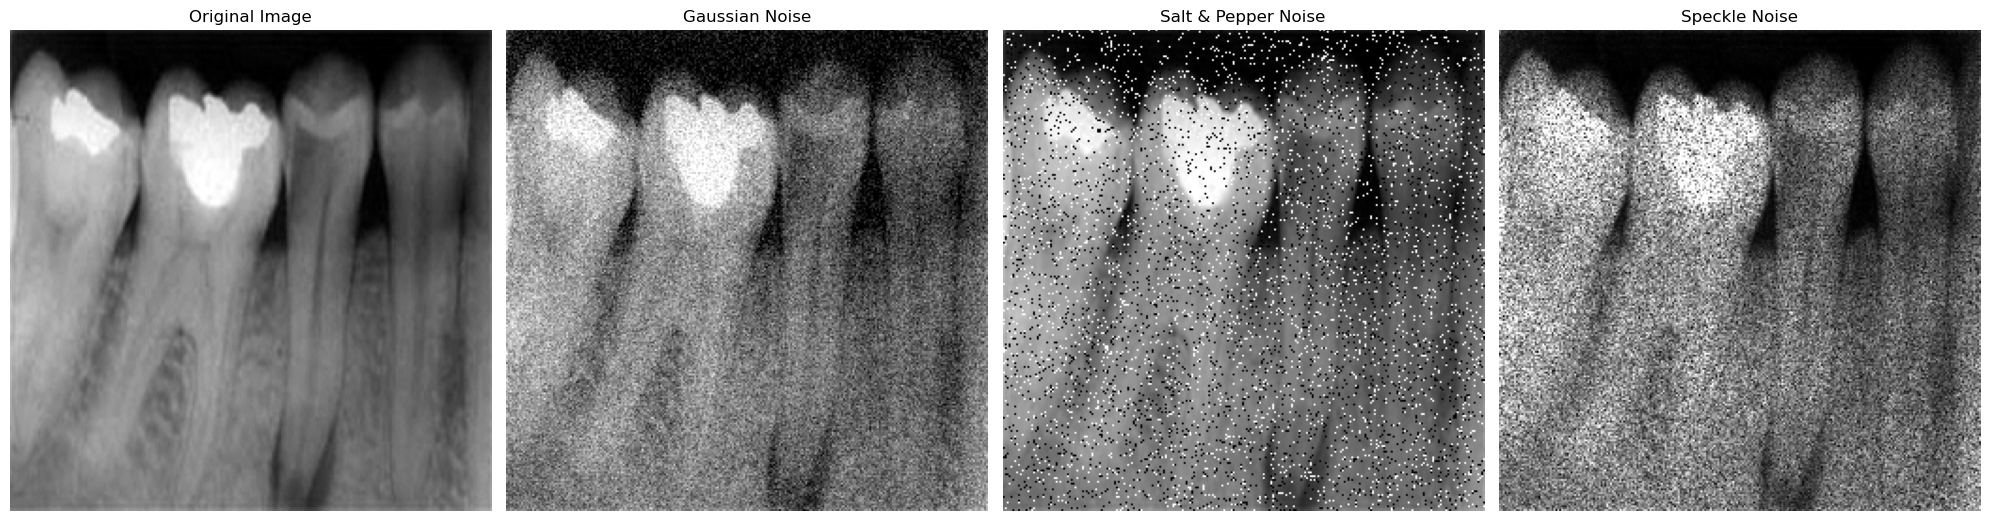

In [ ]:
def add_gaussian_noise(image, mean=0, sigma=0.1):
    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image + noise
    return np.clip(noisy, 0, 1)

def add_salt_pepper_noise(image, prob=0.1):
    noisy = image.copy()
    salt_pepper = np.random.random(image.shape)
    noisy[salt_pepper < prob/2] = 1
    noisy[salt_pepper > 1 - prob/2] = 0
    return noisy

def add_speckle_noise(image, variance=0.1):
    noise = np.random.randn(*image.shape) * np.sqrt(variance)
    noisy = image + image * noise
    return np.clip(noisy, 0, 1)

def display_noisy_images(original, noisy_dict):
    fig, axes = plt.subplots(1, 4, figsize=(20, 20))    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    for idx, (noise_type, noisy_img) in enumerate(noisy_dict.items()):
        axes[idx + 1].imshow(noisy_img, cmap='gray')
        axes[idx + 1].set_title(f'{noise_type} Noise')
        axes[idx + 1].axis('off')
    plt.tight_layout()
    plt.show()
    
if len(images) > 0:
    sample_img = images[4]
    noisy_dict = {
        'Gaussian': add_gaussian_noise(sample_img, sigma=0.1),
        'Salt & Pepper': add_salt_pepper_noise(sample_img),
        'Speckle': add_speckle_noise(sample_img, variance=0.1)}
    display_noisy_images(sample_img, noisy_dict)

## PHASE 2: Denoising the images using BM3D and CNN

### Denoising using BM3D

In [4]:
import bm3d

def denoise_bm3d(noisy_image, sigma_psd=0.1):
    denoised = bm3d.bm3d(noisy_image, sigma_psd=sigma_psd)
    return denoised

### Denoising using CNN

In [ ]:
class SimpleDenoisingCNN(nn.Module):
    def __init__(self):
        super(SimpleDenoisingCNN, self).__init__()
        self.enc1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.enc2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.dec1 = nn.Conv2d(32, 16, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)
        self.dec2 = nn.Conv2d(16, 1, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.use_residual = True
        
    def forward(self, x):
        residual = x
        x1 = self.relu(self.bn1(self.enc1(x)))
        x2 = self.relu(self.bn2(self.enc2(x1)))
        x3 = self.relu(self.bn3(self.dec1(x2)))
        x4 = self.dec2(x3)
        if self.use_residual:
            x4 = x4 + residual
        return x4

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

In [ ]:
class DenoisingDataset(Dataset):
    def __init__(self, images, noise_type='gaussian', noise_param=0.1):
        if images and images[0].max() > 1.0:
            images = [img.astype(np.float32) / 255.0 for img in images]
        self.images = [torch.FloatTensor(img).unsqueeze(0) for img in images]
        self.noise_type = noise_type
        self.noise_param = noise_param
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        clean = self.images[idx]
        if self.noise_type == 'gaussian':
            noise = torch.randn_like(clean) * self.noise_param
            noisy = clean + noise
        elif self.noise_type == 'salt_pepper':
            noisy = clean.clone()
            salt_pepper = torch.rand_like(clean)
            noisy[salt_pepper < 0.05] = 0.0
            noisy[salt_pepper > 0.95] = 1.0
        elif self.noise_type == 'speckle':
            noise = torch.randn_like(clean) * self.noise_param
            noisy = clean + clean * noise
        noisy = torch.clamp(noisy, 0.0, 1.0)
        
        return noisy, clean

In [ ]:
def train_cnn_model_optimized(train_loader, model, epochs=10):
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    model.train()
    train_losses = []
    scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
    start_time = time.time()
    for epoch in range(epochs):
        epoch_loss = 0
        batch_count = 0
        for batch_idx, (noisy, clean) in enumerate(train_loader):
            noisy, clean = noisy.to(device), clean.to(device)
            optimizer.zero_grad()
            if scaler:
                with torch.cuda.amp.autocast():
                    output = model(noisy)
                    loss = criterion(output, clean)
                
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                output = model(noisy)
                loss = criterion(output, clean)
                loss.backward()
                optimizer.step()
            
            epoch_loss += loss.item()
            batch_count += 1
        
        avg_loss = epoch_loss / batch_count
        train_losses.append(avg_loss)
        scheduler.step(avg_loss)
        
        elapsed = time.time() - start_time
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.6f}, Time: {elapsed:.2f}s')
    
    return train_losses

train_images, val_images = train_test_split(images, test_size=0.2, random_state=42)
train_dataset = DenoisingDataset(train_images, noise_type='gaussian')
train_loader = DataLoader(
    train_dataset, 
    batch_size=8,
    shuffle=True,
    num_workers=2 if torch.cuda.is_available() else 0,
    pin_memory=True if torch.cuda.is_available() else False
)

cnn_model = SimpleDenoisingCNN().to(device)
print(f"CNN Parameters: {cnn_model.count_parameters():,}")
train_losses = train_cnn_model_optimized(train_loader, cnn_model, epochs=5)

CNN Parameters: 9,697
Epoch 1/5, Loss: 0.047362, Time: 9.80s
Epoch 2/5, Loss: 0.008845, Time: 18.51s
Epoch 3/5, Loss: 0.004458, Time: 27.59s
Epoch 4/5, Loss: 0.003117, Time: 36.70s
Epoch 5/5, Loss: 0.002553, Time: 46.87s


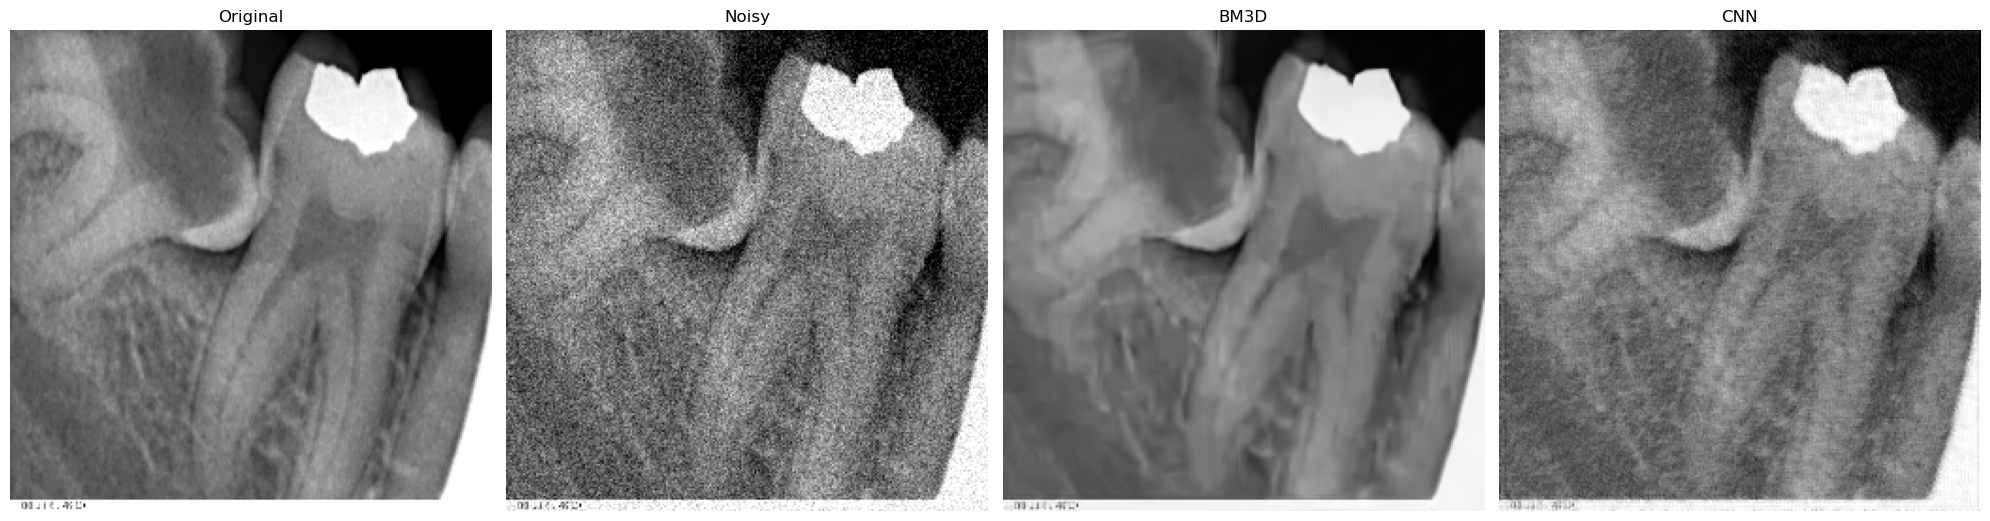

In [ ]:
def test_denoising_methods(test_image, noise_type='gaussian'):
    if noise_type == 'gaussian':
        noisy = add_gaussian_noise(test_image, sigma=0.1)
    elif noise_type == 'salt_pepper':
        noisy = add_salt_pepper_noise(test_image)
    elif noise_type == 'speckle':
        noisy = add_speckle_noise(test_image, variance=0.1)
    bm3d_denoised = denoise_bm3d(noisy, sigma_psd=0.1)
    cnn_model.eval()
    with torch.no_grad():
        noisy_tensor = torch.FloatTensor(noisy).unsqueeze(0).unsqueeze(0).to(device)
        cnn_denoised = cnn_model(noisy_tensor).cpu().squeeze().numpy()
    
    results = {
        'Noisy': noisy,
        'BM3D': np.clip(bm3d_denoised, 0, 1),
        'CNN': np.clip(cnn_denoised, 0, 1)
    }
    
    return results, test_image

if len(val_images) > 0:
    test_img = val_images[0]
    results, original = test_denoising_methods(test_img, noise_type='gaussian')
    fig, axes = plt.subplots(1, 4, figsize=(20, 20))
    
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(results['Noisy'], cmap='gray')
    axes[1].set_title('Noisy')
    axes[1].axis('off')
    
    axes[2].imshow(results['BM3D'], cmap='gray')
    axes[2].set_title('BM3D')
    axes[2].axis('off')
    
    axes[3].imshow(results['CNN'], cmap='gray')
    axes[3].set_title('CNN')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()

### Calculating metrics ( PNSR , SSIM , EPI)

In [ ]:
def edge_preservation_index(original, denoised):
    if len(original.shape) == 3:
        original = color.rgb2gray(original)
    if len(denoised.shape) == 3:
        denoised = color.rgb2gray(denoised)
    original = original.astype(np.float64) / 255.0
    denoised = denoised.astype(np.float64) / 255.0
    grad_x_orig = ndimage.sobel(original, axis=0)
    grad_y_orig = ndimage.sobel(original, axis=1)
    grad_x_den = ndimage.sobel(denoised, axis=0)
    grad_y_den = ndimage.sobel(denoised, axis=1)
    delta_I = np.sqrt(grad_x_orig**2 + grad_y_orig**2)
    delta_I_hat = np.sqrt(grad_x_den**2 + grad_y_den**2)
    mu_delta_I = np.mean(delta_I)
    mu_delta_I_hat = np.mean(delta_I_hat)
    dev_I = np.abs(delta_I - mu_delta_I)
    dev_I_hat = np.abs(delta_I_hat - mu_delta_I_hat)
    numerator = np.sum(dev_I * dev_I_hat)
    denominator = np.sqrt(np.sum(dev_I**2) * np.sum(dev_I_hat**2))
    if denominator == 0:
        return 1.0
    epi = numerator / denominator
    return np.clip(epi, 0, 1)


print(f"Edge Preservation Index (EPI) for BM3D: {edge_preservation_index(original, results['BM3D']):.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR) for BM3D: {psnr(original, results['BM3D']):.4f}")
print(f"Structural Similarity Index (SSIM) for BM3D: {ssim(original, results['BM3D'], data_range=original.max() - original.min()):.4f}")
print('--------------------------------------------------------')
print(f"Edge Preservation Index (EPI) for CNN: {edge_preservation_index(original, results['CNN']):.4f}")
print(f"Peak Signal-to-Noise Ratio (PSNR) for CNN: {psnr(original, results['CNN']):.4f}")
print(f"Structural Similarity Index (SSIM) for CNN: {ssim(original, results['CNN'], data_range=original.max() - original.min()):.4f}")

Edge Preservation Index (EPI) for BM3D: 0.9608
Peak Signal-to-Noise Ratio (PSNR) for BM3D: 30.8546
Structural Similarity Index (SSIM) for BM3D: 0.7776
--------------------------------------------------------
Edge Preservation Index (EPI) for CNN: 0.8769
Peak Signal-to-Noise Ratio (PSNR) for CNN: 25.9596
Structural Similarity Index (SSIM) for CNN: 0.5394


## PHASE 3: Restoration Using Swin Transformer 

In [ ]:
IMG_SIZE = 256
DATASET_PATH = "Dataset"
BATCH_SIZE = 8
EPOCHS = 20

def load_images(folder):
    images = []
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        images.append(img)
    return np.array(images)


clean_images = load_images(DATASET_PATH)
noisy_images = add_gaussian_noise(clean_images)
x_train, x_test, y_train, y_test = train_test_split(noisy_images,clean_images,test_size=0.2,random_state=42)


def swin_block(x, num_heads=4):
    dim = x.shape[-1]
    x_norm = tf.keras.layers.LayerNormalization()(x)
    attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads,key_dim=dim)(x_norm, x_norm)
    x = tf.keras.layers.Add()([x, attn])
    x_norm = tf.keras.layers.LayerNormalization()(x)
    mlp = tf.keras.layers.Dense(dim * 4, activation="gelu")(x_norm)
    mlp = tf.keras.layers.Dense(dim)(mlp)
    x = tf.keras.layers.Add()([x, mlp])
    return x


def patch_embedding(x, patch_size=4, embed_dim=64):
    x = tf.keras.layers.Conv2D(embed_dim,kernel_size=patch_size,strides=patch_size,padding="same")(x)
    shape = x.shape
    x = tf.keras.layers.Reshape((shape[1] * shape[2], embed_dim))(x)
    return x, shape

def build_swin_denoiser():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x, shape = patch_embedding(inputs)
    x = swin_block(x)
    x = swin_block(x)
    h = shape[1]
    w = shape[2]
    c = shape[3]
    x = tf.keras.layers.Reshape((h, w, c))(x)
    x = tf.keras.layers.Conv2DTranspose(64,kernel_size=4,strides=4,padding="same")(x)
    outputs = tf.keras.layers.Conv2D(3,kernel_size=3,padding="same",activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    return model

model = build_swin_denoiser()

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()
history = model.fit(x_train,y_train,validation_data=(x_test, y_test),epochs=EPOCHS,batch_size=BATCH_SIZE)
denoised = model.predict(x_test)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 32, 32,    │      3,136 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1024, 64)  │          0 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1024, 64)  │        128 │ reshape[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024, 64)  │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 64)  │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024, 256) │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024, 64)  │     16,448 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024, 64)  │          0 │ add[0][0],        │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 64)  │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1024, 64)  │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 1024, 64)  │          0 │ add_1[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1024, 64)  │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024, 256) │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024, 64)  │     16,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1024, 64)  │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 32, 32,    │          0 │ add_3[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 269,891 (1.03 MB)

 Trainable params: 269,891 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step - loss: 0.0422 - mae: 0.1585 - val_loss: 0.0071 - val_mae: 0.0618
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0071 - mae: 0.0625 - val_loss: 0.0059 - val_mae: 0.0575
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - loss: 0.0053 - mae: 0.0541 - val_loss: 0.0045 - val_mae: 0.0478
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - loss: 0.0043 - mae: 0.0480 - val_loss: 0.0042 - val_mae: 0.0453
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - loss: 0.0041 - mae: 0.0465 - val_loss: 0.0051 - val_mae: 0.0543
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - loss: 0.0045 - mae: 0.0507 - val_loss: 0.0048 - val_mae: 0.0523
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0040 - mae: 0.0470 - val_loss: 0.0037 - val_mae: 0.0426
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0034 - mae: 0.0419 - val_loss: 0.0036 - val_mae: 0.0431
Epoch 9/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - loss: 0.0039 - mae: 

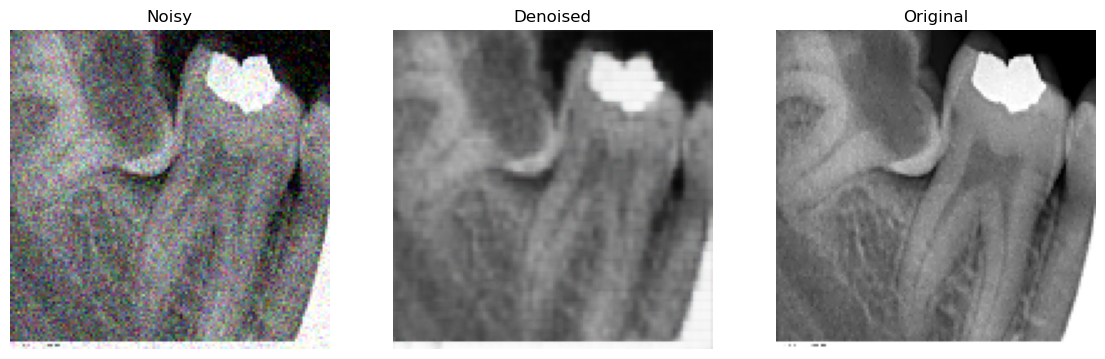

In [11]:
plt.figure(figsize=(14, 10))

plt.subplot(1, 3, 1)
plt.imshow(x_test[0])
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(denoised[0])
plt.title("Denoised")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(y_test[0])
plt.title("Original")
plt.axis("off")

plt.show()

In [12]:
print(f"PSNR: {psnr(y_test[0], denoised[0], data_range=1.0):.4f}")
print(f"SSIM: {ssim(y_test[0],denoised[0],data_range=1.0,win_size=7, channel_axis=-1):.4f}")
print(f"Edge Preservation Index (EPI): {edge_preservation_index(y_test[0], denoised[0]):.4f}")

PSNR: 27.2142
SSIM: 0.7560
Edge Preservation Index (EPI): 0.9071
